# Homework 4

## FINM 35700 - Spring 2026

### UChicago Financial Mathematics

### Due Date: 2026-04-21

* Alex Popovici
* alex.popovici@uchicago.edu

This homework relies on:

Interest Rate & Credit Default Swaps
- the SOFR OIS symbology file `sofr_swap_symbology`,
- the SOFR swaps market data file `sofr_swaps_market_data_eod`,
- the CDS spreads market data file `cds_market_data_eod`.

HYG ETF corporate bonds:
- the HYG bond symbology file `hyg_bond_symbology` and
- the HYG basket composition file (containing bond weights and yields) `hyg_basket_composition`.

In [2]:
# import tools from previous homeworks
from credit_market_tools import *
import matplotlib.pyplot as plt
from IPython.display import display

# Use static calculation/valuation date of 2026-03-23, matching data available in the market prices EOD file
calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date

# Calculation/valuation date as pd datetime
as_of_date = pd.to_datetime('2026-03-23')

-----------------------------------------------------------
# Problem 1: Fixed rate bond prices and sensitivities (bond yield model)

## When computing sensitivities, assume "everything else being equal" (ceteris paribus).

For a better understanding of dependencies, you can use the simple fixed rate bond valuation formula in the flat yield model (formula [6] in Lecture 1).

\begin{align}
PV_{Bond}\left(c,T,y_{sa} \right)=1+\frac{c-y_{sa}}{y_{sa}}\cdot\left[1-\left(1+\frac{y_{sa}}{2}\right)^{-2T}\right]
\end{align}


## a. True or False (fixed rate bond prices)

1. Fixed rate bond price is increasing in yield. **False**
2. Fixed rate bond price is increasing in coupon **True**
3. Fixed rate bond price is increasing in bond maturity **True**
4. Fixed rate callable bond prices are higher or equal to their "bullet" (non-callable) version. **True**


## b. True or False (fixed rate bond yields)

1. Fixed rate bond yield is increasing in interest rate (assuming credit spread unchanged) **False**   
2. Fixed rate bond yield is increasing in credit spread (assuming interest rate unchanged)  **True**  
3. Fixed rate bond yield is increasing in coupon **False**
4. Fixed rate bond yield is increasing in bond maturity (assume term structure of yield curve is known) **True**


## c. True or False (fixed rate bond durations)

1. Fixed rate bond duration is increasing with yield **True**
2. Fixed rate bond duration is increasing in coupon **True**
3. Fixed rate bond duration is increasing with bond maturity **True**
4. Fixed rate callable bond durations are higher or equal to their "bullet" (non-callable) version. **False**


## d. True or False (fixed rate bond convexities)

1. Fixed rate bond convexity is increasing with yield
2. Fixed rate bond convexity is increasing in coupon
3. Fixed rate bond convexity is increasing with bond maturity
4. Fixed rate callable bond convexities are higher or equal to their "bullet" (non-callable) version.


-----------------------------------------------------------
# Problem 2: US SOFR swap curve calibration as of 2026-03-23
### Follow Section "1. SOFR OIS swap rates and SOFR discount curve calibration + validation" in the QuantLib Advanced notebook !

## a. Load and explore US SOFR swaps symbology and market data

Load the `sofr_swap_symbology` Excel file into a dataframe. Print all swap tenors available.

Load the `sofr_swaps_market_data_eod` Excel file into a dataframe. Print all dates available.

Plot the historial time series of SOFR rates for the available [1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y] tenors.

In [3]:
sofr_swaps_symbology = pd.read_excel('data/sofr_swaps_symbology.xlsx')
print(sofr_swaps_symbology['tenor'].unique().tolist())
sofr_swaps_market_data_eod = pd.read_excel('data/sofr_swaps_market_data_eod.xlsx')
print(sofr_swaps_market_data_eod['date'].unique().tolist())

[1, 2, 3, 5, 7, 10, 20, 30]
[Timestamp('2024-01-02 00:00:00'), Timestamp('2024-01-03 00:00:00'), Timestamp('2024-01-04 00:00:00'), Timestamp('2024-01-05 00:00:00'), Timestamp('2024-01-08 00:00:00'), Timestamp('2024-01-09 00:00:00'), Timestamp('2024-01-10 00:00:00'), Timestamp('2024-01-11 00:00:00'), Timestamp('2024-01-12 00:00:00'), Timestamp('2024-01-16 00:00:00'), Timestamp('2024-01-17 00:00:00'), Timestamp('2024-01-18 00:00:00'), Timestamp('2024-01-19 00:00:00'), Timestamp('2024-01-22 00:00:00'), Timestamp('2024-01-23 00:00:00'), Timestamp('2024-01-24 00:00:00'), Timestamp('2024-01-25 00:00:00'), Timestamp('2024-01-26 00:00:00'), Timestamp('2024-01-29 00:00:00'), Timestamp('2024-01-30 00:00:00'), Timestamp('2024-01-31 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-02-02 00:00:00'), Timestamp('2024-02-05 00:00:00'), Timestamp('2024-02-06 00:00:00'), Timestamp('2024-02-07 00:00:00'), Timestamp('2024-02-08 00:00:00'), Timestamp('2024-02-09 00:00:00'), Timestamp('2024-02-

In [4]:
display(sofr_swaps_symbology.head())    
display(sofr_swaps_market_data_eod.head())

,figi,ticker,class,bbg,name,tenor,type,dcc,exchange,country,currency,status
0,BBG00KFWPJJ9,USOSFR1,Curncy,USOSFR1 Curncy,USD OIS ANN VS SOFR 1Y,1,SWAP,ACT/360,NONE,US,USD,ACTV
1,BBG00KFWPJX3,USOSFR2,Curncy,USOSFR2 Curncy,USD OIS ANN VS SOFR 2Y,2,SWAP,ACT/360,NONE,US,USD,ACTV
2,BBG00KFWPK15,USOSFR3,Curncy,USOSFR3 Curncy,USD OIS ANN VS SOFR 3Y,3,SWAP,ACT/360,NONE,US,USD,ACTV
3,BBG00KFWPK51,USOSFR5,Curncy,USOSFR5 Curncy,USD OIS ANN VS SOFR 5Y,5,SWAP,ACT/360,NONE,US,USD,ACTV
4,BBG00KFWPK79,USOSFR7,Curncy,USOSFR7 Curncy,USD OIS ANN VS SOFR 7Y,7,SWAP,ACT/360,NONE,US,USD,ACTV


,date,figi,bidRate,askRate,midRate
0,2024-01-02,BBG00KFWPJJ9,4.7960,4.8046,4.80030
1,2024-01-02,BBG00KFWPJX3,4.1368,4.1452,4.14100
2,2024-01-02,BBG00KFWPK15,3.8258,3.8327,3.82925
3,2024-01-02,BBG00KFWPK51,3.5907,3.5943,3.59250
4,2024-01-02,BBG00KFWPK79,3.5297,3.5333,3.53150


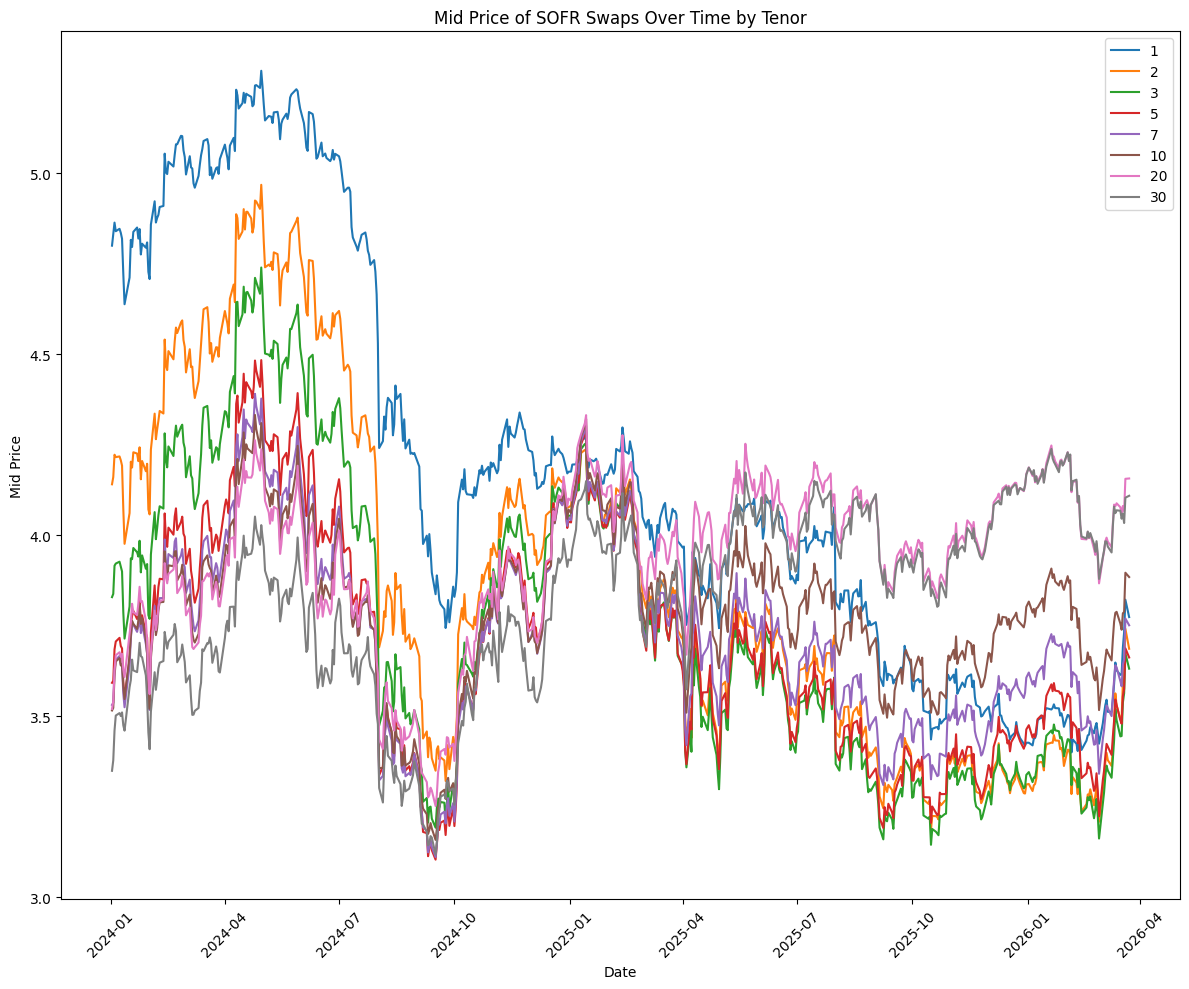

In [5]:
combined = sofr_swaps_market_data_eod.merge(sofr_swaps_symbology, on='figi', how='left')
tenors = combined['tenor'].unique().tolist()
plt.figure(figsize=(12, 10))
for tenor in tenors:
    subset = combined[combined['tenor'] == tenor]
    plt.plot(subset['date'], subset['midRate'], label=tenor)
plt.xlabel('Date')
plt.ylabel('Mid Price')
plt.title('Mid Price of SOFR Swaps Over Time by Tenor')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## b. Calibrate the US SOFR yield curve (via bootstrapping)
The function below shows how to calibrate a smooth yield/discount factor curve from SOFR swaps. 

Prepare a joint symbology & market dataframe quotes as of 2026-03-23. 

Calibrate the SOFR discount factor curve as of 2026-03-23.

Follow section 1b in the QuantLib Advanced notebook.

In [6]:
def calibrate_sofr_curve_from_frame(
        calc_date: ql.Date,
        sofr_details: pd.DataFrame,
        rate_quote_column: str):
    '''Create a calibrated yield curve from a SOFR details dataframe which includes rate quotes.
    '''
    ql.Settings.instance().evaluationDate = calc_date

    # Sort dataframe by maturity
    sorted_details_frame = sofr_details.sort_values(by='tenor')    
    
    # settle_days
    settle_days = 1
    
    # For US SOFR OIS Swaps 
    day_count = ql.Actual360()

    # For US SOFR Swaps     
    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    
    sofr_helpers = []
    
    for index, row in sorted_details_frame.iterrows():
        sofr_quote = row[rate_quote_column]
        tenor_in_years = row['tenor']
        sofr_tenor = ql.Period(tenor_in_years, ql.Years)
        
        # create sofr_rate_helper
        sofr_helper = ql.OISRateHelper(settle_days, sofr_tenor, ql.QuoteHandle(ql.SimpleQuote(sofr_quote/100)), ql.Sofr())
                        
        sofr_helpers.append(sofr_helper)
        
    sofr_yield_curve = ql.PiecewiseLinearZero(settle_days, calendar, sofr_helpers, day_count)
    sofr_yield_curve.enableExtrapolation()

    handle = ql.YieldTermStructureHandle(sofr_yield_curve)

    return sofr_yield_curve, handle

sofr_curve_result = calibrate_sofr_curve_from_frame(calc_date, combined[combined['date'] == '2026-03-23'], 'midRate')[0]
sofr_curve_handle = calibrate_sofr_curve_from_frame(calc_date, combined[combined['date'] == '2026-03-23'], 'midRate')[1]


## c. Display the calibrated SOFR discount curve dataframe

Follow section 1d (in the QuantLib Advanced notebook) to display the calibration details dataframe.

In [7]:
def get_yield_curve_details_df(yield_curve, curve_dates=None):
    
    if(curve_dates == None):
        curve_dates = yield_curve.dates()

    dates = [d.to_date() for d in curve_dates]
    discounts = [round(yield_curve.discount(d), 3) for d in curve_dates]
    yearfracs = [round(yield_curve.timeFromReference(d), 3) for d in curve_dates]
    zeroRates = [round(yield_curve.zeroRate(d, yield_curve.dayCounter(), ql.Compounded).rate() * 100, 3) for d in curve_dates]

    yield_curve_details_df = pd.DataFrame(data={'Date': dates,
                             'YearFrac': yearfracs,
                             'DiscountFactor': discounts,
                             'ZeroRate': zeroRates})                             
    return yield_curve_details_df

sofr_curve_details_df = get_yield_curve_details_df(sofr_curve_result)
display(sofr_curve_details_df.head())

,Date,YearFrac,DiscountFactor,ZeroRate
0,2026-03-24,0.000,1.000,3.773
1,2027-03-24,1.014,0.963,3.773
2,2028-03-24,2.031,0.929,3.684
3,2029-03-26,3.050,0.897,3.627
4,2031-03-24,5.072,0.833,3.662


## d. Plot the calibrated US SOFR Zero Interest Rates and Discount Factor curves

Plot the SOFR zero rates and discount factor curves by maturity. Follow section 1c in the QuantLib Advanced notebook.

Text(0, 0.5, 'Discount Factor')

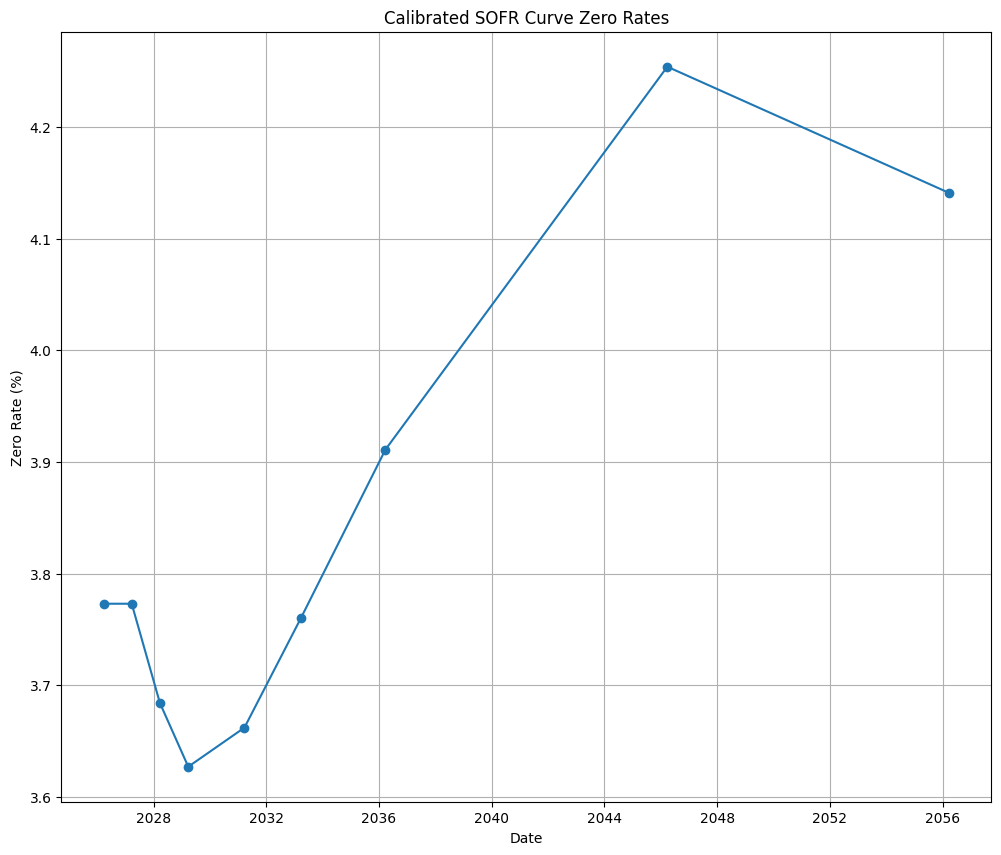

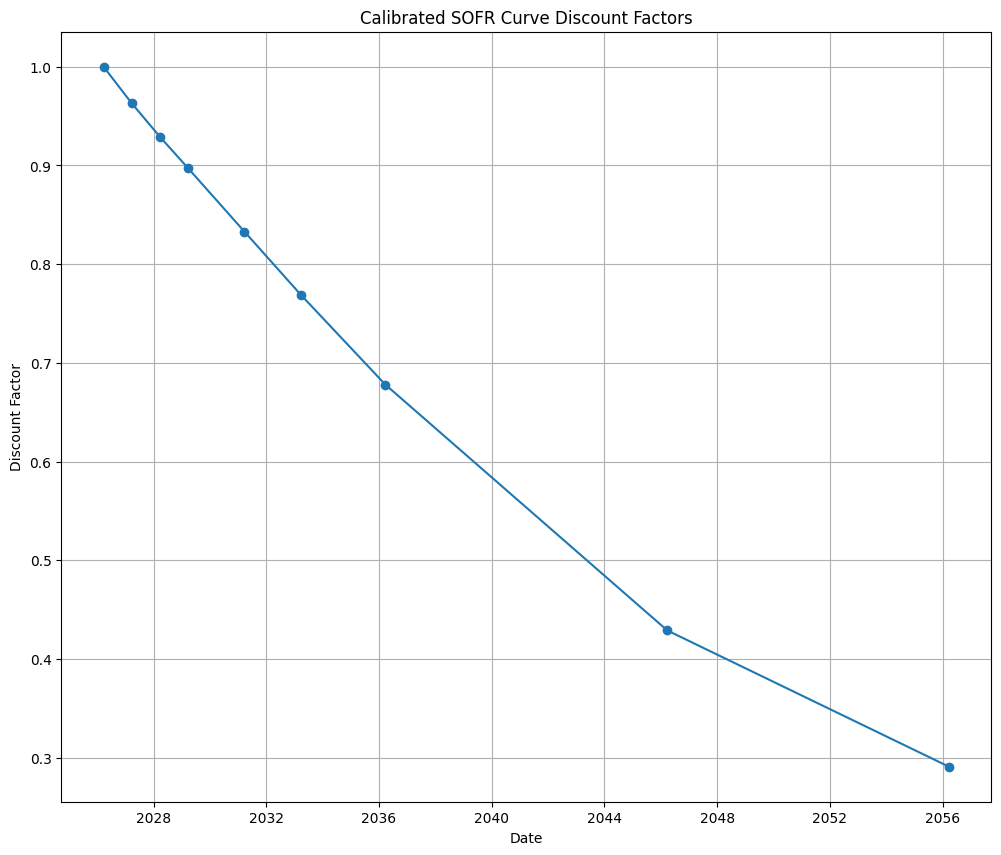

In [8]:
rate = sofr_curve_details_df.plot(x='Date', y='ZeroRate', title='Calibrated SOFR Curve Zero Rates', legend=False, figsize=(12, 10), grid=True, style='o-')
rate.set_xlabel('Date')
rate.set_ylabel('Zero Rate (%)')


discount = sofr_curve_details_df.plot(x='Date', y='DiscountFactor', title='Calibrated SOFR Curve Discount Factors', legend=False, figsize=(12, 10), grid=True, style='o-')
discount.set_xlabel('Date')
discount.set_ylabel('Discount Factor')  

-----------------------------------------------------------
# Problem 3: CDS Hazard Rate calibration and valuation
## Follow Section "2. CDS Hazard Rate calibration + Pricing" in the QuantLib Advanced notebook !!!

## a. Load and explore the CDS market data (IBM credit issuer)

Load the `cds_market_data_eod` Excel file into a dataframe. It contains CDS Par Spreads (in bps) for IBM credit issuer, from January 2024 until March 2026.

Plot the historical time series of CDS Par Spreads for the available tenors.


In [9]:
cds_market_data_eod = pd.read_excel('data/cds_market_data_eod.xlsx')
cds_market_data_eod.head()

,date,ticker,short_name,tier,currency,doc_clause,running_coupon,cds_assumed_recovery,par_spread_1y,par_spread_2y,par_spread_3y,par_spread_5y,par_spread_7y,par_spread_10y
0,2024-01-02,IBM,Intl Business Machs Corp,SNRFOR,USD,XR14,100,0.4,13.6831,18.8194,28.3917,44.7053,62.1494,69.1972
1,2024-01-03,IBM,Intl Business Machs Corp,SNRFOR,USD,XR14,100,0.4,14.2256,19.6610,29.4493,46.4866,63.6475,71.4311
2,2024-01-04,IBM,Intl Business Machs Corp,SNRFOR,USD,XR14,100,0.4,13.8318,19.1828,28.8454,45.4735,62.6543,70.9180
3,2024-01-05,IBM,Intl Business Machs Corp,SNRFOR,USD,XR14,100,0.4,13.6181,18.7703,28.3417,44.7575,61.9778,70.2746
4,2024-01-08,IBM,Intl Business Machs Corp,SNRFOR,USD,XR14,100,0.4,13.4433,18.3692,27.7599,43.8548,60.8378,68.8914


(array([19723., 19814., 19905., 19997., 20089., 20179., 20270., 20362.,
        20454., 20544.]),
 [Text(19723.0, 0, '2024-01'),
  Text(19814.0, 0, '2024-04'),
  Text(19905.0, 0, '2024-07'),
  Text(19997.0, 0, '2024-10'),
  Text(20089.0, 0, '2025-01'),
  Text(20179.0, 0, '2025-04'),
  Text(20270.0, 0, '2025-07'),
  Text(20362.0, 0, '2025-10'),
  Text(20454.0, 0, '2026-01'),
  Text(20544.0, 0, '2026-04')])

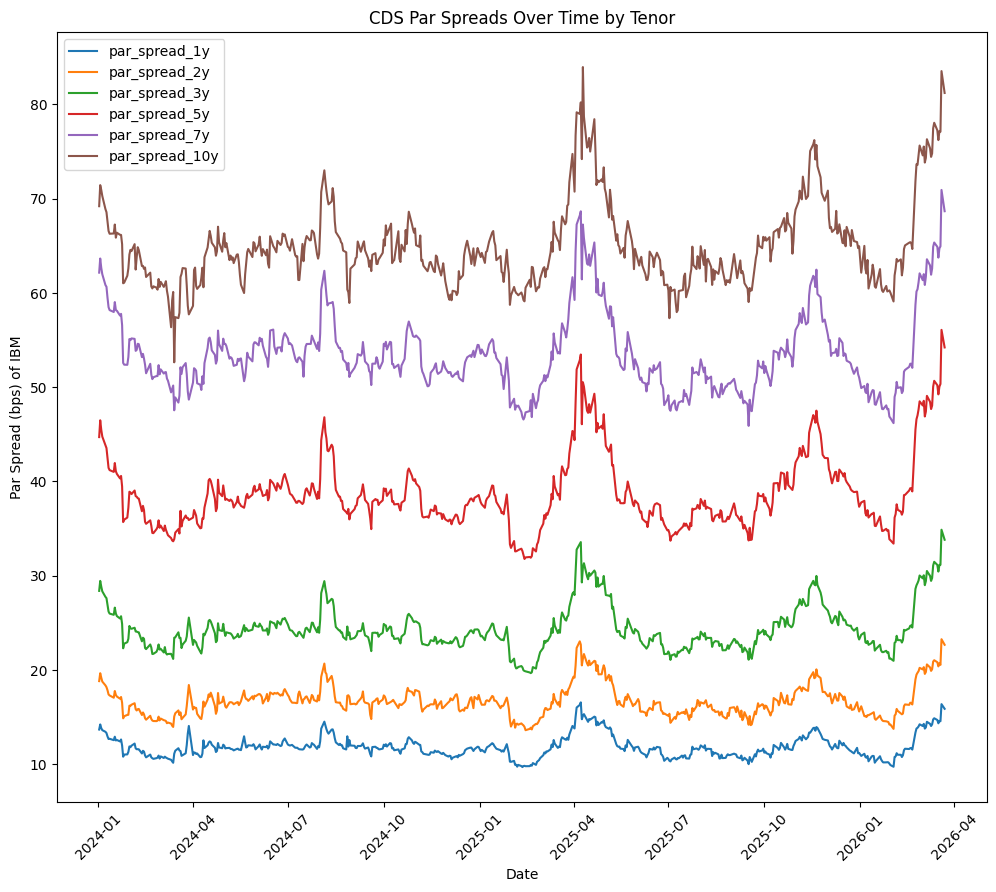

In [10]:
plt.figure(figsize=(12, 10))
for cols in ['par_spread_1y', 'par_spread_2y', 'par_spread_3y', 'par_spread_5y', 
             'par_spread_7y', 'par_spread_10y']:
    plt.plot(cds_market_data_eod['date'], cds_market_data_eod[cols], label=cols)
plt.xlabel('Date')
plt.ylabel('Par Spread (bps) of IBM')
plt.title('CDS Par Spreads Over Time by Tenor')
plt.legend()
plt.xticks(rotation=45)

## b. Calibrate the IBM hazard rate curve as of 2026-03-23

Follow section 2a in the QuantLib Advanced notebook. Use the calibrated SOFR discount curve from Problem 2b.

In [18]:
def calibrate_hazard(
        calc_date: ql.Date,
        cds_details: pd.DataFrame,
        sofr_curve=None):
    '''Calibrate a hazard curve from a CDS details dataframe which includes par spread quotes.
    '''

    CDS_recovery_rate = 0.4

    ql.Settings.instance().evaluationDate = calc_date
        
    settle_days = 1
    
    day_count = ql.Actual360()
     
    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    
    hazard_helpers = []
    
    for col in ['par_spread_1y', 'par_spread_2y', 'par_spread_3y', 'par_spread_5y', 
             'par_spread_7y', 'par_spread_10y']:
        cds_quote = cds_details[col].values[0]
        tenor_in_years = int(col.split('_')[2][:-1])
        cds_tenor = ql.Period(tenor_in_years, ql.Years)
        
        # create cds_helper
        cds_helper = ql.SpreadCdsHelper(
            ql.QuoteHandle(ql.SimpleQuote(cds_quote / 10000)),
            cds_tenor,
            settle_days,
            calendar,
            ql.Quarterly,
            ql.Following,
            ql.DateGeneration.TwentiethIMM,        
            day_count,
            CDS_recovery_rate,
            sofr_curve_handle
        )

                        
        hazard_helpers.append(cds_helper)
        
    hazard_curve = ql.PiecewiseFlatHazardRate(settle_days, calendar, hazard_helpers, day_count)
    hazard_curve.enableExtrapolation()

        # Display calibrated hazard rates and survival probabilities
    hazard_list = [(hr[0].to_date(), 
                    day_count.yearFraction(calc_date, hr[0]),
                    hr[1] * 100,
                    hazard_curve.survivalProbability(hr[0])) 
                    for hr in hazard_curve.nodes()]

    grid_dates, year_frac, hazard_rates, surv_probs = zip(*hazard_list)

    hazard_rates_df = pd.DataFrame(data={'Date': grid_dates, 
                                        'YearFrac': year_frac,
                                        'HazardRate': hazard_rates,
                                        'SurvivalProb': surv_probs})
    
    return hazard_curve, hazard_rates_df

hazard_rate_curve = calibrate_hazard(calc_date, cds_market_data_eod[cds_market_data_eod['date'] == '2026-03-23'], sofr_curve_result)[0]
hazard_curve_result = calibrate_hazard(calc_date, cds_market_data_eod[cds_market_data_eod['date'] == '2026-03-23'], sofr_curve_result)[1]
hazard_curve_result.head()


,Date,YearFrac,HazardRate,SurvivalProb
0,2026-03-24,0.002778,0.263483,1.000000
1,2027-06-21,1.263889,0.263483,0.996683
2,2028-06-20,2.277778,0.522819,0.991413
3,2029-06-20,3.291667,1.005213,0.981361
4,2031-06-20,5.319444,1.520002,0.951574


## c. Plot the calibrated Hazard Rates and Survival Probability curves
Follow section 2b in the QuantLib Advanced notebook. Use the calibrated SOFR discount curve from Problem 2b.

Text(0.5, 0, 'Date')

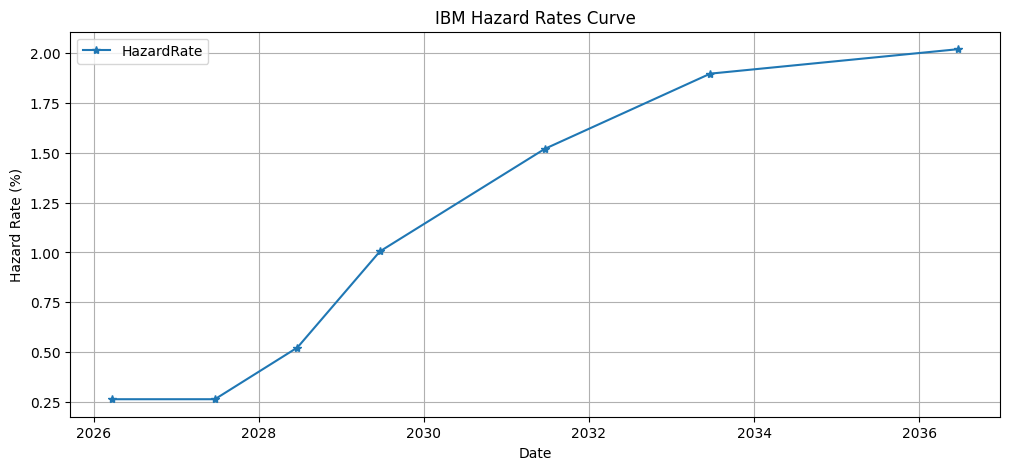

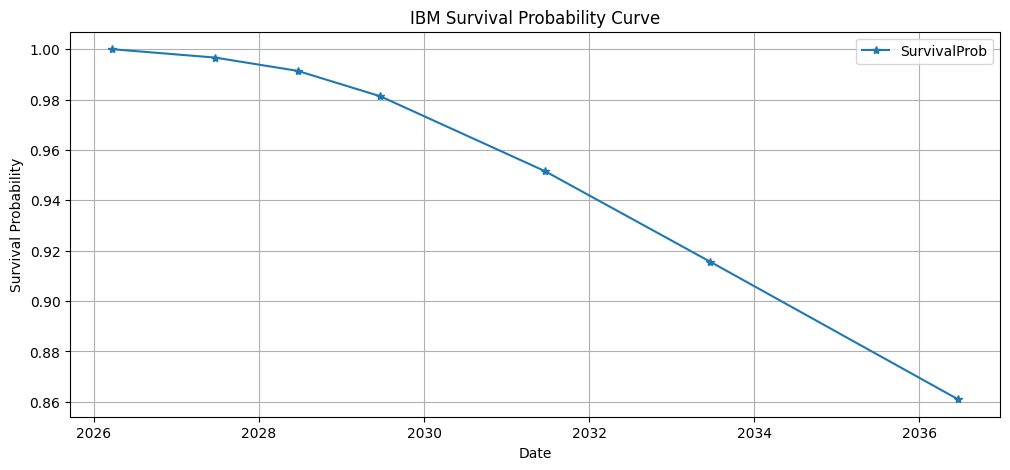

In [16]:
plt = hazard_curve_result.plot(x='Date', y='HazardRate', grid=True, style='*-', title='IBM Hazard Rates Curve', figsize=(12,5))
plt.set_ylabel('Hazard Rate (%)')
plt.set_xlabel('Date')

plt = hazard_curve_result.plot(x='Date', y='SurvivalProb', grid=True, style='*-', title='IBM Survival Probability Curve', figsize=(12,5))
plt.set_ylabel('Survival Probability')
plt.set_xlabel('Date')

## d. Compute the fair/par spread and PV of a 5 year CDS contract

Follow section 2c in the QuantLib Advanced notebook. Construct a CDS object with 100 bps coupon and 2031-06-20 maturity.

Compute the following CDS metrics:
- fair/par spread,
- PV,
- Premium Leg PV,
- Default Leg PV,
- Issuer survival probability to maturity.


In [21]:
side = ql.Protection.Seller

face_notional = 100

cds_maturity_date = ql.Date(20, 6, 2031)

cds_schedule = ql.MakeSchedule(calc_date, cds_maturity_date, ql.Period('3M'), 
                               ql.Quarterly, ql.TARGET(), ql.Following, ql.Unadjusted,
                               ql.DateGeneration.TwentiethIMM)

cds_obj = ql.CreditDefaultSwap(side, face_notional, 0.01, cds_schedule, ql.Following, ql.Actual360())

cds_surv_prob_curve_handle = ql.DefaultProbabilityTermStructureHandle(hazard_rate_curve)

cds_pricing_engine = ql.MidPointCdsEngine(cds_surv_prob_curve_handle, 0.4, sofr_curve_handle)

cds_obj.setPricingEngine(cds_pricing_engine)

print('CDS protection start date:', cds_obj.protectionStartDate())
print('CDS fair/par spread:', round(cds_obj.fairSpread()*10000, 3))
print('CDS PV:', round(cds_obj.NPV(), 4))    
print('CDS Premium Leg PV:', round(cds_obj.couponLegNPV(), 4))
print('CDS Default Leg PV', round(cds_obj.defaultLegNPV(), 4))
print('Survival Prob. to Maturity:', round(hazard_rate_curve.survivalProbability(cds_maturity_date), 4))

CDS protection start date: March 23rd, 2026
CDS fair/par spread: 54.185
CDS PV: 2.1725
CDS Premium Leg PV: 4.7419
CDS Default Leg PV -2.5694
Survival Prob. to Maturity: 0.9516


-----------------------------------------------------------
# Problem 4: Credit ETF analysis on HYG (iShares High Yield Corporate Bond ETF)

## a. Load and explore the HYG basket composition and market data

Load the `hyg_basket_composition` Excel file into a dataframe. It contains the HYG basket constituent face notionals, weights and yields-to-maturities as of 2026-03-23.

Load the `hyg_corp_symbology` Excel file into a dataframe. It contains the corporate bond details for HYG constituents.

How many corporate bonds are in the HYG basket?  What are the average and median face notionals for a bond?

How many unique tickers are in the HYG basket? What are the average and median face notionals for a ticker?

Compute mean, median and standard deviation of yields-to-maturity of bonds in the basket.

In [24]:
hyg_basket_composition = pd.read_excel('data/hyg_basket_composition.xlsx')
hyg_corp_symbology = pd.read_excel('data/hyg_corp_symbology.xlsx')
display(hyg_basket_composition.head())
display(hyg_corp_symbology.head())

,date,etf_ticker,figi,isin,security,description,coupon,maturity,cpn_type,class,currency,bidYield,askYield,midYield,face_notional,face_notional_weight
0,2024-12-13,HYG,BBG00ZKWG886,US013822AG68,AA 4 1/8 03/31/29,ALCOA NEDERLAND HOLDING BV 4.125 03/31/2029 14...,4.125,2029-03-31,FIXED,Corp,USD,5.654,5.481,5.5675,8280000,0.049525
1,2024-12-13,HYG,BBG00VYJS3B3,US013822AE11,AA 5 1/2 12/15/27,ALCOA NEDERLAND HOLDING BV 5.5 12/15/2027 144a...,5.500,2027-12-15,FIXED,Corp,USD,5.724,5.074,5.3990,8631000,0.051627
2,2024-12-13,HYG,BBG00KXCGK19,US013822AC54,AA 6 1/8 05/15/28,ALCOA NEDERLAND HOLDING BV 6.125 05/15/2028 14...,6.125,2028-05-15,FIXED,Corp,USD,5.870,5.323,5.5965,5826000,0.034846
3,2024-12-13,HYG,BBG01LW38YD3,US013822AH42,AA 7 1/8 03/15/31,ALCOA NEDERLAND HOLDING BV 7.125 03/15/2031 14...,7.125,2031-03-15,FIXED,Corp,USD,6.055,5.830,5.9425,13064000,0.078141
4,2024-12-13,HYG,BBG01F5TZPJ2,US023771T329,AAL 7 1/4 02/15/28,AMERICAN AIRLINES INC 7.25 02/15/2028 144a (SE...,7.250,2028-02-15,FIXED,Corp,USD,5.995,5.793,5.8940,14392000,0.086081


,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status
0,AA,Corp,BBG00ZKWG886,US013822AG68,US91282CMA61,AA 4 1/8 03/31/29,ALCOA NEDERLAND HOLDING,PRIV PLACEMENT,4.125,FIXED,...,2021-03-24,2021-09-30,2021-03-24,2029-03-31,CALLABLE,Sr Unsecured,500.0,NE,USD,ACTV
1,AA,Corp,BBG00VYJS3B3,US013822AE11,US91282CMB45,AA 5 1/2 12/15/27,ALCOA NEDERLAND HOLDING,PRIV PLACEMENT,5.500,FIXED,...,2020-07-13,2020-12-15,2020-07-13,2027-12-15,CALLABLE,Sr Unsecured,750.0,NE,USD,ACTV
2,AA,Corp,BBG00KXCGK19,US013822AC54,US91282CLY56,AA 6 1/8 05/15/28,ALCOA NEDERLAND HOLDING,PRIV PLACEMENT,6.125,FIXED,...,2018-05-17,2018-11-15,2018-05-17,2028-05-15,CALLABLE,Sr Unsecured,500.0,NE,USD,ACTV
3,AA,Corp,BBG01LW38YD3,US013822AH42,US91282CMA61,AA 7 1/8 03/15/31,ALCOA NEDERLAND HOLDING,PRIV PLACEMENT,7.125,FIXED,...,2024-03-21,2024-09-15,2024-03-21,2031-03-15,CALLABLE,Sr Unsecured,750.0,NE,USD,ACTV
4,AAL,Corp,BBG01F5TZPJ2,US023771T329,US91282CMB45,AAL 7 1/4 02/15/28,AMERICAN AIRLINES INC,PRIV PLACEMENT,7.250,FIXED,...,2023-02-15,2023-08-15,2023-02-15,2028-02-15,CALLABLE,1st lien,750.0,US,USD,ACTV


In [ ]:
# Merge symbology into basket
hyg = hyg_basket_composition.merge(hyg_corp_symbology, on='figi', how='left')

# ── Bond-level stats ──────────────────────────────────────────────────────────
n_bonds = len(hyg)
avg_face_bond   = hyg['face_notional'].mean()
med_face_bond   = hyg['face_notional'].median()
print(f'Number of bonds in HYG basket : {n_bonds}')
print(f'Average face notional per bond : ${avg_face_bond:>15,.0f}')
print(f'Median  face notional per bond : ${med_face_bond:>15,.0f}')

# ── Ticker-level stats ────────────────────────────────────────────────────────
ticker_notionals = hyg.groupby('ticker')['face_notional'].sum()
n_tickers        = len(ticker_notionals)
avg_face_ticker  = ticker_notionals.mean()
med_face_ticker  = ticker_notionals.median()
print(f'\nNumber of unique tickers       : {n_tickers}')
print(f'Average face notional per ticker: ${avg_face_ticker:>14,.0f}')
print(f'Median  face notional per ticker: ${med_face_ticker:>14,.0f}')

# ── YTM statistics ────────────────────────────────────────────────────────────
ytm_mean = hyg['ytm'].mean()
ytm_med  = hyg['ytm'].median()
ytm_std  = hyg['ytm'].std()
print(f'\nYield-to-Maturity statistics (% annualised):')
print(f'  Mean   YTM : {ytm_mean:.4f}%')
print(f'  Median YTM : {ytm_med:.4f}%')
print(f'  Std    YTM : {ytm_std:.4f}%')


## b. Compute the NAV of the HYG basket and the intrinsic price of one ETF share.

Create the bond objects for all constituents of HYG. For each bond, compute the clean price, accrued and dirty price (convert from yield-to-maturity). Remember that dirty price = clean price + accrued.

Aggregate the ETF NAV value (intrisic value of bond basket) as the weighted sum of dirty prices times basket weights. Keep in mind that the resulting ETF NAV will be on a face of $100, since the basket face notional weights add up to 100 percent.

Compute the intrinisc market capitalization of the HYG ETF by scaling the ETF NAV price to the ETF total face notional. 

Divide by 202,500,000 (the number of ETF shared outstanding as of 2026-03-23) to obtain the intrinsic USD price of one HYG ETF share.

As a reference, the market/close price of each HYG share on 2026-03-23 was $79.44, and the NAV was $79.34.

In [ ]:
import QuantLib as ql
import numpy as np

ETF_SHARES_OUTSTANDING = 202_500_000

def make_bond(row, calc_date):
    """Build a QuantLib FixedRateBond from a merged HYG symbology row."""
    ql.Settings.instance().evaluationDate = calc_date

    settle_days  = int(row.get('settlement_days', 2))
    calendar     = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    coupon_rate  = float(row['coupon_rate']) / 100.0       # stored as %
    maturity     = ql.Date(row['maturity_date'].day,
                           row['maturity_date'].month,
                           row['maturity_date'].year)
    face         = 100.0
    freq         = ql.Semiannual                           # standard US corp
    day_count    = ql.Thirty360(ql.Thirty360.USA)          # standard US corp

    schedule = ql.MakeSchedule(calc_date, maturity,
                                ql.Period(freq),
                                calendar,
                                ql.Unadjusted, ql.Unadjusted,
                                ql.DateGeneration.Backward, False)

    bond = ql.FixedRateBond(settle_days, face, schedule,
                             [coupon_rate], day_count)
    return bond


def price_bond_from_ytm(bond, ytm_pct, calc_date, settle_days=2):
    """Return (clean_price, accrued, dirty_price) given a YTM in percent."""
    ql.Settings.instance().evaluationDate = calc_date
    calendar      = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    settle_date   = calendar.advance(calc_date, ql.Period(settle_days, ql.Days))
    day_count     = ql.Thirty360(ql.Thirty360.USA)

    ytm           = ytm_pct / 100.0
    clean_price   = bond.cleanPrice(ytm, day_count, ql.Compounded, ql.Semiannual, settle_date)
    accrued       = bond.accruedAmount(settle_date)
    dirty_price   = clean_price + accrued
    return clean_price, accrued, dirty_price


# ── Build bond objects and price each constituent ────────────────────────────
records = []
bond_objects = []           # (bond, weight) for downstream use

for _, row in hyg.iterrows():
    bond   = make_bond(row, calc_date)
    ytm    = float(row['ytm'])                  # YTM already in %
    weight = float(row['weight']) / 100.0       # weight stored as %

    cp, acc, dp = price_bond_from_ytm(bond, ytm, calc_date)

    records.append({'figi': row['figi'],
                    'ticker': row['ticker'],
                    'ytm': ytm,
                    'weight': weight,
                    'clean_price': round(cp, 4),
                    'accrued': round(acc, 4),
                    'dirty_price': round(dp, 4)})
    bond_objects.append((bond, weight))

bond_prices_df = pd.DataFrame(records)
display(bond_prices_df.head(10))

# ── Aggregate to ETF NAV ─────────────────────────────────────────────────────
# NAV on $100 face (weights sum to 1 after /100)
etf_nav = (bond_prices_df['weight'] * bond_prices_df['dirty_price']).sum()

# Scale to total basket face notional
total_face_notional = hyg['face_notional'].sum()
etf_market_cap      = etf_nav / 100.0 * total_face_notional

# Intrinsic share price
etf_share_price     = etf_market_cap / ETF_SHARES_OUTSTANDING

print(f'ETF NAV (on $100 face)         : ${etf_nav:.4f}')
print(f'Total basket face notional     : ${total_face_notional:,.0f}')
print(f'ETF intrinsic market cap       : ${etf_market_cap:,.0f}')
print(f'Intrinsic HYG share price      : ${etf_share_price:.4f}')
print()
print('Reference: market close = $79.44 | published NAV = $79.34')


## c. Compute the ETF yield using the ACF (Aggregated Cash-Flows) method

Create the bond objects for all constituents of HYG. 

Write a function that computes the ETF NAV for a given flat yield y.

Use a numerical root finder (e.g. root_scalar from scipy.optimize) to solve for 

- ETF_NAV(yield) = ETF_NAV_Price 

and obtain the ETF yield.

As a reference, the HYG market yield as of 2026-03-23 was around 7%.

Add a root finder wrapper function (e.g. root_scalar in scipy.optimize ) and solve for the ETF yield.

In [ ]:
from scipy.optimize import root_scalar

def compute_etf_nav_at_yield(flat_ytm_pct, bond_objects_weights, calc_date):
    """
    Reprice every constituent at the same flat yield and return the
    weighted-average dirty price (= ETF NAV on $100 face).

    This is the Aggregated-Cash-Flow (ACF) approach: using a single flat
    yield across all bonds is equivalent to discounting every constituent's
    future cash flows at that common rate.
    """
    ql.Settings.instance().evaluationDate = calc_date
    nav = 0.0
    for bond, weight in bond_objects_weights:
        cp, acc, dp = price_bond_from_ytm(bond, flat_ytm_pct, calc_date)
        nav += weight * dp
    return nav


# ── Root-find: NAV(y) = etf_nav ──────────────────────────────────────────────
def objective(y_pct):
    return compute_etf_nav_at_yield(y_pct, bond_objects, calc_date) - etf_nav

result    = root_scalar(objective, bracket=[1.0, 20.0], method='brentq', xtol=1e-8)
etf_yield = result.root          # in percent

print(f'ETF ACF yield: {etf_yield:.4f}%')
print(f'(Reference HYG market yield as of 2026-03-23: ~7.00%)')


## d. Compute the ETF Duration

Treat the ETF basket as a synthetic bond.

Use - 1 bp scenarios in ETF yield space to compute the ETF Duration.

As a reference, the HYG Duration as of 2026-03-23 was around 3.1.

In [ ]:
# ── Duration via -1 bp scenario ───────────────────────────────────────────────
BUMP_BP = 1.0 / 100.0          # 1 bp in percent units

nav_base     = compute_etf_nav_at_yield(etf_yield,          bond_objects, calc_date)
nav_bump_dn  = compute_etf_nav_at_yield(etf_yield - BUMP_BP, bond_objects, calc_date)

# Modified duration = -dP/dy / P  ≈  (P(y-1bp) - P(y)) / (P(y) * 0.0001)
etf_duration = (nav_bump_dn - nav_base) / (nav_base * BUMP_BP / 100.0)

print(f'ETF NAV at base yield              : ${nav_base:.6f}')
print(f'ETF NAV at yield - 1bp             : ${nav_bump_dn:.6f}')
print(f'ETF Modified Duration (years)      : {etf_duration:.4f}')
print()
print('Reference HYG Duration as of 2026-03-23: ~3.1')
